# AIRCRAFT RISK ANALYSIS (2018-2022)

 1.  BUSINESS UNDERSTANDING
Retrospective study to analysis commercial and private aviation enterprise for the period of 2018 to 2022 so as to form blue print in determining aircraft type with lowest risk of operation

      General Objective

      To determining aircraft type with lowest risk of operation for commercial and private company

      Specific Objective
      1.  To Identify aircraft_type with lowest and highest fatalities
      2.  To establish damage level for aircraft 
      3.  To establish fatalities by the month of the year
      4.  To establish location with lowest and highest fatalities

    Business question

 1. Which aircraft_type had lowest cases of fatality?
 2. what are damage level for aircraft type?
 3. What are fatalities by month of the year?
 4. which location had lowest and highest fatalities?

2. DATA UNDERSTANDING - 
       Data Source is from Kaggle flight dataset

3.  DATA PREPARATION

        Data was uploaded using pandas library

In [1]:
import pandas as pd

# Load raw dataset (do not edit files in /data)
df_original = pd.read_csv("../data/flight.csv")

# Create working copy for cleaning & analysis
df = df_original.copy()

In [2]:
# To protect raw version
df_original = df.copy(deep=True)

In [3]:
import numpy as np

In [4]:
# To view first five rows
df_original.head()

,Unnamed: 0,acc.date,type,reg,operator,fat,location,dmg
0,0,3 Jan 2022,British Aerospace 4121 Jetstream 41,ZS-NRJ,SA Airlink,0,near Venetia Mine Airport,sub
1,1,4 Jan 2022,British Aerospace 3101 Jetstream 31,HR-AYY,LANHSA - Línea Aérea Nacional de Honduras S.A,0,Roatán-Juan Manuel Gálvez International Airpor...,sub
2,2,5 Jan 2022,Boeing 737-4H6,EP-CAP,Caspian Airlines,0,Isfahan-Shahid Beheshti Airport (IFN),sub
3,3,8 Jan 2022,Tupolev Tu-204-100C,RA-64032,"Cainiao, opb Aviastar-TU",0,Hangzhou Xiaoshan International Airport (HGH),w/o
4,4,12 Jan 2022,Beechcraft 200 Super King Air,NaN,private,0,"Machakilha, Toledo District, Grahem Creek area",w/o


In [5]:
df_original.shape        # how many rows & columns

(2500, 8)

In [6]:
df_original.info()       # data types + missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2500 non-null   int64 
 1   acc.date    2500 non-null   object
 2   type        2500 non-null   object
 3   reg         2408 non-null   object
 4   operator    2486 non-null   object
 5   fat         2488 non-null   object
 6   location    2500 non-null   object
 7   dmg         2500 non-null   object
dtypes: int64(1), object(7)
memory usage: 156.4+ KB


In [7]:
# This how many rows have the exact same values in every column in raw dataset
df_original.duplicated().sum()

np.int64(1250)

In [8]:
df_original.isnull().sum()


Unnamed: 0     0
acc.date       0
type           0
reg           92
operator      14
fat           12
location       0
dmg            0
dtype: int64

        To have overview of missing columns and its percentage as per original dataset

In [9]:
missing_values = df_original.isna().sum()
missing_percentage = (df_original.isna().sum() / len(df_original)) * 100

missing_df_original = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percentage': missing_percentage
})

print(missing_df_original)

            missing_count  missing_percentage
Unnamed: 0              0                0.00
acc.date                0                0.00
type                    0                0.00
reg                    92                3.68
operator               14                0.56
fat                    12                0.48
location                0                0.00
dmg                     0                0.00


In [10]:
import pandas as pd
import numpy as np

# Define hidden missing markers
hidden_missing = ["Unknown", "N/A", "-", ""]

# Replace them with proper NaN
df.replace(hidden_missing, pd.NA, inplace=True)

# Count all missing values (real + hidden)
print(df.isnull().sum())


Unnamed: 0     0
acc.date       0
type           0
reg           94
operator      52
fat           12
location       0
dmg            0
dtype: int64


In [11]:
df_original.describe()   # statistic for numeric columns

,Unnamed: 0
count,2500.000000
mean,624.500000
std,360.915993
min,0.000000
25%,312.000000
50%,624.500000
75%,937.000000
max,1249.000000


In [12]:
df_original.describe(include='all') # statistic for catergorical and numerical columns

,Unnamed: 0,acc.date,type,reg,operator,fat,location,dmg
count,2500.000000,2500,2500,2408,2486,2488,2500,2500
unique,NaN,871,523,1194,827,47,1059,6
top,NaN,3 Mar 2020,Cessna 208B Grand Caravan,unreg.,private,0,"Chicago-O'Hare International Airport, IL (ORD/...",sub
freq,NaN,24,114,6,206,2068,28,1330
mean,624.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,360.915993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,312.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,624.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,937.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df_original.columns.tolist()      # column names

['Unnamed: 0', 'acc.date', 'type', 'reg', 'operator', 'fat', 'location', 'dmg']

        From the look,columns are abbreviated, therefore there are not self expanatory
        i will rename to more relevant name

In [14]:
df = df_original.rename(columns={
    'Unnamed: 0': 'id',
    'acc.date': 'accident_date',
    'type': 'aircraft_type',
    'reg': 'registration_number',
    'operator': 'aircraft_operator',
    'fat': 'fatalities',
    'dmg': 'damage_level'
})

In [15]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2500 non-null   int64 
 1   acc.date    2500 non-null   object
 2   type        2500 non-null   object
 3   reg         2408 non-null   object
 4   operator    2486 non-null   object
 5   fat         2488 non-null   object
 6   location    2500 non-null   object
 7   dmg         2500 non-null   object
dtypes: int64(1), object(7)
memory usage: 156.4+ KB


In [16]:
# Strip spaces from all string/object columns
## By selects all columns of type string/object and removes leading/trailing spaces from each string column

# Apply .str.strip() only to object (string) columns
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').apply(lambda x: x.str.strip())

# To have title case formatting entire string columns

# Select only string columns
string_cols = df.select_dtypes(include='object').columns

# Apply title case
df[string_cols] = df[string_cols].apply(lambda x: x.str.title())

        Columns Remarks
        Observation made per column against expectation

        Column one (1)

In [17]:
# column 1
df_original['Unnamed: 0'].unique() # To understand contents of this column

array([   0,    1,    2, ..., 1247, 1248, 1249], shape=(1250,))

In [18]:
# to see content of Unnamed: 0
df_original['Unnamed: 0']

0          0
1          1
2          2
3          3
4          4
        ... 
2495    1245
2496    1246
2497    1247
2498    1248
2499    1249
Name: Unnamed: 0, Length: 2500, dtype: int64

        This just look index_number, of no value to analysis
        i need to drop

In [19]:
#drop id column
df.drop(columns=['id'], inplace=True)

        Column two (2)

In [20]:
df_original['acc.date'].unique()

array(['3 Jan 2022', '4 Jan 2022', '5 Jan 2022', '8 Jan 2022',
       '12 Jan 2022', '16 Jan 2022', '19 Jan 2022', '22 Jan 2022',
       '27 Jan 2022', '31 Jan 2022', '2 Feb 2022', '5 Feb 2022',
       '7 Feb 2022', '8 Feb 2022', '11 Feb 2022', '14 Feb 2022',
       '15 Feb 2022', '16 Feb 2022', '18 Feb 2022', '21 Feb 2022',
       '23 Feb 2022', '24 Feb 2022', '26 Feb 2022', '27 Feb 2022',
       '28 Feb 2022', '1 Mar 2022', '2 Mar 2022', '3 Mar 2022',
       '5 Mar 2022', '6 Mar 2022', '7 Mar 2022', '8 Mar 2022',
       '9 Mar 2022', '12 Mar 2022', '17 Mar 2022', '21 Mar 2022',
       '26 Mar 2022', '30 Mar 2022', '1 Apr 2022', '2 Apr 2022',
       '7 Apr 2022', '8 Apr 2022', '11 Apr 2022', '13 Apr 2022',
       '14 Apr 2022', '17 Apr 2022', '22 Apr 2022', '26 Apr 2022',
       '30 Apr 2022', '1 May 2022', '3 May 2022', '6 May 2022',
       '10 May 2022', '11 May 2022', '12 May 2022', '20 May 2022',
       '21 May 2022', '24 May 2022', '25 May 2022', '27 May 2022',
       '28 May 202

        Observation 
        Already that date is object from df_original.info()
        Invalid values xx june 2022, xx jan 2021
        Unk. date 2018

        solution is clean and change datatype to datetime
        To note that there are six (6) missing date

In [21]:
# working on cleaned dataframe
df['accident_date'] = df_original['acc.date']

In [22]:
# Converting accident date from object data to datetime
df['accident_date'] = pd.to_datetime(df['accident_date'], errors='coerce')

In [23]:
# Missing of days in months make data invalid
df['accident_date'] = pd.to_datetime(
    df_original['acc.date'],
    format='%d %b %Y',
    errors='coerce'
)

In [24]:
# to which rows are missing, from the look there are six date
df[df['accident_date'].isna()]

,accident_date,aircraft_type,registration_number,aircraft_operator,fatalities,location,damage_level
101,NaT,Antonov An-2R,Ra-17951,Voskhod Llc,0,Near Oymyakon Airfield,Sub
233,NaT,Antonov An-2,NaN,Korean People'S Army Air And Anti-Air Force (K...,5,Near Taechon Air Base,W/O
1249,NaT,Rockwell Sabreliner 80,N337Kl,Private,0,"Eugene Airport, Or (Eug)",Sub
1351,NaT,Antonov An-2R,Ra-17951,Voskhod Llc,0,Near Oymyakon Airfield,Sub
1483,NaT,Antonov An-2,NaN,Korean People'S Army Air And Anti-Air Force (K...,5,Near Taechon Air Base,W/O
2499,NaT,Rockwell Sabreliner 80,N337Kl,Private,0,"Eugene Airport, Or (Eug)",Sub


In [25]:

df['year'] = df['accident_date'].dt.year
df['month'] = df['accident_date'].dt.month_name()

In [26]:
# convert to real datetime
df['accident_date'] = pd.to_datetime(df['accident_date'], format='%d %b %Y', errors='coerce')

In [27]:
# to extract time features
df['year']  = df['accident_date'].dt.year.astype('Int64')
df['month'] = df['accident_date'].dt.month.astype('Int64')
df['month_name'] = df['accident_date'].dt.month_name()
df['day_of_week'] = df['accident_date'].dt.day_name()

In [28]:

# To handle unknown dates
df['date_missing_flag'] = df['accident_date'].isna().astype(int)

        Column three (3) - Aircraft Type

In [29]:
df_original['type'].unique()

array(['British Aerospace 4121 Jetstream 41',
       'British Aerospace 3101 Jetstream 31', 'Boeing 737-4H6',
       'Tupolev Tu-204-100C', 'Beechcraft 200 Super King Air',
       'Airbus A320-214 (WL)', 'Cessna 208B Grand Caravan EX',
       'Airbus A320-232', 'Bombardier CL-600-2B16 Challenger 604',
       'Beechcraft B300 King Air 350', 'Hawker 1000',
       'Cessna 208B Grand Caravan', 'Embraer ERJ-190-100LR',
       'Antonov An-26', 'Cessna 501 Citation I/SP', 'Antonov An-2R',
       'Let L-410UVP-E3', 'ATR 42-500', 'Britten-Norman BN-2A-9 Islander',
       'Swearingen SA226-AT Merlin IV', 'Embraer EMB-500 Phenom 100E',
       'de Havilland Canada DHC-3T Texas Turbine Otter',
       'Raytheon Hawker 800XP', 'Antonov An-2', 'Antonov An-22A',
       'Antonov An-26-100', 'Antonov An-74T', 'Cessna 208B Supervan 900',
       'Antonov An-124-100', 'Antonov An-225',
       'Embraer ERJ 170-200 LR (ERJ-175LR)', 'Shaanxi Y-8Q',
       'Embraer EMB-500 Phenom 100', 'Boeing 737-8AS (WL)',
  

In [30]:
df_original['type'].value_counts(dropna=False)

type
Cessna 208B Grand Caravan                   114
Antonov An-2R                                58
Beechcraft 200 Super King Air                58
de Havilland Canada DHC-6 Twin Otter 300     34
Cessna 208 Caravan I                         30
                                           ... 
Boeing 767-375ER                              2
Boeing 747-412 (BCF)                          2
Boeing 747-412F (SCD)                         2
Boeing 737-76N (WL)                           2
Rockwell Sabreliner 80                        2
Name: count, Length: 523, dtype: int64

In [31]:
# Check for duplicate values in the 'type' column
# First occurrence is marked False, subsequent duplicates marked True
df_original['type'].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2495     True
2496     True
2497     True
2498     True
2499     True
Name: type, Length: 2500, dtype: bool

        Observation 
            Duplicate


        Solution
            Removing duplicate

        Column Four (4) Registation_number

In [32]:
df_original['reg'].value_counts(dropna=False)

reg
NaN       92
unreg.     6
C-FKWE     4
N233SW     4
N817NW     4
          ..
N705CK     2
N71VT      2
PR-YRH     2
N743QS     2
N337KL     2
Name: count, Length: 1195, dtype: int64

        Observation 
            NaN - missing value is 92 which translate to 3.68% and six (6) cases of unreg aircraft

        Solution 
            since it is visible accident occured by unknown plane i can include in total
            standardizing missing and unregistered value

In [33]:
df['registration_number'] = df_original['reg'].replace({
    'unreg.': 'Unregistered'
})

# Fill missing values with 'Unknown'
df['registration_number'] = df['registration_number'].fillna('Unknown')

In [34]:
# Registration number should not be in title format
df['registration_number'] = df['registration_number'].str.upper()

In [35]:
# Filling missing value with Unknown
df['registration_number'] = df['registration_number'].fillna('Unknown')

        Column Five (5) -Operator

In [36]:
df_original['operator'].value_counts(dropna=False)

operator
private                                             206
American Airlines                                    44
Delta Air Lines                                      44
Unknown                                              38
Southwest Airlines                                   36
                                                   ... 
Helidosa Aviation Group                               2
Cottingham & Butler Insurance Services                2
Malu Aviation                                         2
Aeromedevac Air Ambulance                             2
Guardia Nacional Bolivariana de Venezuela - GNBV      2
Name: count, Length: 828, dtype: int64

In [37]:
df_original['operator'].unique()

array(['SA Airlink', 'LANHSA - Línea Aérea Nacional de Honduras S.A',
       'Caspian Airlines', 'Cainiao, opb Aviastar-TU', 'private',
       'Star Flyer', 'Mahan Air', 'JetBlue Airways', 'Volare Aviation',
       'Lima Delta Co Trustee',
       'Air Tindi, opf Royal Canadian Air Force - RCAF', 'Skyview LLC',
       'Care Aviation', 'Finnair', 'South Sudanese Air Force',
       'Aviajet SA', 'Kamchatsky Krechet', 'Doren Air Congo',
       'Japan Air Commuter', 'Air Flamenco', 'Colcharter',
       'Eclipse Transport LLC', 'Bald Mountain Air Services',
       'Roper Aviation LLC', 'Air Serv Limited', 'Taraz Zhana Alem',
       'Antonov Airlines', 'GoJump Oceanside', 'Russian Air Force',
       'Ukraine Air Force', 'AB Aviation', 'Revolution Flight',
       'American Eagle, opb Republic Airlines', 'Spirit Avia Sentosa',
       'China Naval Air Force - Unit 92967', 'Flyzar', 'Ryanair',
       'Indian Coast Guard', 'HLAF AETA LLC', 'Ozark Air Services',
       'Bamaji Air', 'Jet It LLC', '

        Observation 
        Unknown operator are 38 whic are equivalent to 0.56%

        Solution 
        Concerning above cell aircraft_operator, filling missing value with Unknown since accident occured
        Keeping it unknown operator is justifiable since injury of death occured due to operator

In [38]:
df['aircraft_operator'] = df_original['operator'] # Keeping original data while working on one to be cleaned


In [39]:
# standardizing missing value
df['aircraft_operator'] = df['aircraft_operator'].replace({
    np.nan: 'Unknown'
})

In [40]:
# Filling missing value with Unknown
df['aircraft_operator'] = df['aircraft_operator'].fillna('Unknown')


        Column Six (6) - Fatalities (Death)

In [41]:
df_original['fat'].value_counts(dropna=False)

fat
0       2068
1         86
2         70
3         38
4         38
5         24
0+1       16
6         14
7         12
9         12
NaN       12
10         8
11         8
8          8
0+2        6
12         6
18         4
20         4
15         4
14         4
13         4
22         2
1+5        2
5+14       2
21+6       2
39         2
38         2
71         2
66         2
51         2
257        2
112        2
41         2
21         2
1+2        2
157        2
26         2
97+1       2
176        2
1+1        2
16         2
28         2
50+3       2
62         2
5+1        2
19         2
132        2
189        2
Name: count, dtype: int64

In [42]:
df_original['fat'].unique()

array(['0', '2', nan, '5', '14', '11', '132', '1', '22', '6', '4', '8',
       '0+2', '10', '3', '0+1', '19', '5+1', '62', '7', '12', '50+3',
       '28', '16', '9', '1+1', '18', '176', '97+1', '21', '26', '15',
       '157', '1+2', '13', '41', '1+5', '5+14', '21+6', '38', '71', '66',
       '39', '51', '257', '112', '20', '189'], dtype=object)

In [43]:
# Ensure everything is a string first
df_original['fat'] = df_original['fat'].astype(str)

In [44]:
# Convert combined values like '0+1' into a sum, safely handle 'nan'
df_original['fat'] = df_original['fat'].apply(lambda x: sum(int(i) for i in x.split('+')) if x != 'nan' else 0)

        Observation 
        Majority of values are interger despite datatype show object just because of missing value 
        At some point, its like two fatalities are reported together 0+2, 0+1, 5+1

        Solution filling 
        Since no justification of death, i replace missing fatality with zero (0) since absence of record indicate no death occurred

In [45]:
df['fatalities'] = df_original['fat'].fillna(0) # replacing missing fatalities with 

        Column Seven (7) -Location

In [46]:
df_original['location'].value_counts(dropna=False)

location
Chicago-O'Hare International Airport, IL (ORD/KORD)    28
Nashville-John C. Tune Airport, TN (KJWN)              24
Denver International Airport, CO (DEN/KDEN)            16
Vancouver International Airport, BC (YVR/CYVR)         14
Houston-William P. Hobby Airport, TX (HOU)             14
                                                       ..
Dubuque, IA                                             2
Cancún Airport (CUN/MMUN)                               2
Fulshear, TX                                            2
14,8 km NW of Shabunda                                  2
Beni Airport (BNC)                                      2
Name: count, Length: 1059, dtype: int64

In [47]:
df_original['location'].unique()

array(['near Venetia Mine Airport',
       'Roatán-Juan Manuel Gálvez International Airport (RTB)',
       'Isfahan-Shahid Beheshti Airport (IFN)', ...,
       '2 km NE of Atlanta-Fulton County Airport, GA (FTY)',
       'Kamarata Airport (KTV)', 'Beni Airport (BNC)'],
      shape=(1059,), dtype=object)

        Observation- it's noted that location is integers

        Solution
        Standardizing missing location
        Removing codes from location
        Removing Extra Airport codes
        Splitting city into state
        Removing description and remain with name

In [48]:
# Create your cleaned column without changing original
df['location_clean'] = (
    df['location']
      .str.lower()
      .str.strip()
)

In [49]:
# Working on clean column
df['location_clean'] = df_original['location']

In [50]:
#Standardize missing
df['location_clean'] = df['location_clean'].fillna('Unknown Location')

In [51]:
#Removing codes from location name
df['location_clean'] = df['location_clean'].str.replace(r'\s*\(.*\)', '', regex=True)

In [52]:
#Removing extra Airport code
df['airport_code'] = df['location_clean'].str.extract(r'\(([^/()]+)')

In [53]:
# Splitting city into state
df[['city', 'state']] = df['location_clean'].str.extract(r'^(.*?),\s*([A-Z]{2})$')


In [54]:
# interested with place name not distance description
df['location_clean'] = df['location_clean'].str.replace(r'.*of\s+', '', regex=True)

In [55]:
# drop raw column from working df
df = df.drop(columns=['location'])

        Column Eight (8) - Damage_Level

In [56]:
# Column 8
df_original['dmg'].value_counts(dropna=False)

dmg
sub    1330
w/o     702
non     338
min      98
unk      30
mis       2
Name: count, dtype: int64

In [57]:
df_original['dmg'].unique()

array(['sub', 'w/o', 'non', 'min', 'unk', 'mis'], dtype=object)

        Observation 
        Categories of damage were abbreviated and this cannot sense to everyone, 

        Solution
        All unclear categories should be secronized to have one name 'unknown'
        To conceptualize entire extent of damage, it is preferable to use full name of these categorize for easy comprehension

In [58]:
# For all unclear categories it worth to combine to have one name
df_original['dmg'] = df_original['dmg'].replace({'unk': 'unknown', 'mis': 'unknown'})

In [59]:
df['damage_level'] = df_original['dmg'].replace({
    'sub': 'Substantial Damage',
    'w/o': 'Aircraft Destroyed',
    'non': 'No Damage',
    'min': 'Minor Damage',
    'unk': 'Unknown',
    'mis': 'Unknown'
})

        Overview of cleaned data

        Normalize all string/object columns at once

In [60]:
df.columns.tolist()

['accident_date',
 'aircraft_type',
 'registration_number',
 'aircraft_operator',
 'fatalities',
 'damage_level',
 'year',
 'month',
 'month_name',
 'day_of_week',
 'date_missing_flag',
 'location_clean',
 'airport_code',
 'city',
 'state']

In [61]:
# Check updated DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   accident_date        2494 non-null   datetime64[ns]
 1   aircraft_type        2500 non-null   object        
 2   registration_number  2500 non-null   object        
 3   aircraft_operator    2500 non-null   object        
 4   fatalities           2500 non-null   int64         
 5   damage_level         2500 non-null   object        
 6   year                 2494 non-null   Int64         
 7   month                2494 non-null   Int64         
 8   month_name           2494 non-null   object        
 9   day_of_week          2494 non-null   object        
 10  date_missing_flag    2500 non-null   int64         
 11  location_clean       2500 non-null   object        
 12  airport_code         0 non-null      object        
 13  city                 934 non-null

In [62]:
df['accident_date'].unique()

<DatetimeArray>
['2022-01-03 00:00:00', '2022-01-04 00:00:00', '2022-01-05 00:00:00',
 '2022-01-08 00:00:00', '2022-01-12 00:00:00', '2022-01-16 00:00:00',
 '2022-01-19 00:00:00', '2022-01-22 00:00:00', '2022-01-27 00:00:00',
 '2022-01-31 00:00:00',
 ...
 '2018-12-06 00:00:00', '2018-12-08 00:00:00', '2018-12-10 00:00:00',
 '2018-12-11 00:00:00', '2018-12-15 00:00:00', '2018-12-18 00:00:00',
 '2018-12-20 00:00:00', '2018-12-22 00:00:00', '2018-12-24 00:00:00',
 '2018-12-31 00:00:00']
Length: 869, dtype: datetime64[ns]

        Concentrating on aircraft_Operator

In [63]:
# Standardizing casing
df['aircraft_operator'] = df['aircraft_operator'].str.lower()

In [64]:
# removing Extra description
df['aircraft_operator'] = df['aircraft_operator'].str.replace(r', op[bf]|, lsf', '', regex=True)

In [65]:
# Removing extra spaces
df['aircraft_operator'] = df['aircraft_operator'].str.strip()

In [66]:
duplicates = df['aircraft_operator'].duplicated().sum()
print(duplicates)

1679


In [67]:
unique_operators = df['aircraft_operator'].unique()
len(unique_operators)

821

In [68]:
df['aircraft_operator'].value_counts()


aircraft_operator
private                                             214
unknown                                              54
delta air lines                                      44
american airlines                                    44
united airlines                                      36
                                                   ... 
dimed sa distribuidora da medicamentos                2
helidosa aviation group                               2
cottingham & butler insurance services                2
malu aviation                                         2
guardia nacional bolivariana de venezuela - gnbv      2
Name: count, Length: 821, dtype: int64

In [69]:
# Remove extra tags
df['aircraft_operator'] = df['aircraft_operator'].str.replace(r', op[bf]|, lsf', '', regex=True)

# Convert to lowercase and strip spaces
df['aircraft_operator'] = df['aircraft_operator'].str.lower().str.strip()


In [70]:
df['aircraft_operator'] = df['aircraft_operator'].replace(
    {'private': 'private/unknown', 'unknown': 'private/unknown'}
)

In [71]:
# To check for duplicate
duplicates = df['aircraft_operator'].duplicated().sum()
print(duplicates)


1680


In [72]:
df['aircraft_operator'][df['aircraft_operator'].duplicated()]

27                                       antonov airlines
28                                       antonov airlines
33                                       antonov airlines
34                                       antonov airlines
48                                             martinaire
                              ...                        
2495                                   chen aircrafts llc
2496     guardia nacional bolivariana de venezuela - gnbv
2497    air force of the democratic republic of the congo
2498                                    american airlines
2499                                      private/unknown
Name: aircraft_operator, Length: 1680, dtype: object

In [73]:
df[df.duplicated()]  # shows full row duplicates

,accident_date,aircraft_type,registration_number,aircraft_operator,fatalities,damage_level,year,month,month_name,day_of_week,date_missing_flag,location_clean,airport_code,city,state
1250,2022-01-03,British Aerospace 4121 Jetstream 41,ZS-NRJ,sa airlink,0,Substantial Damage,2022,1,January,Monday,0,near Venetia Mine Airport,NaN,NaN,NaN
1251,2022-01-04,British Aerospace 3101 Jetstream 31,HR-AYY,lanhsa - línea aérea nacional de honduras s.a,0,Substantial Damage,2022,1,January,Tuesday,0,Roatán-Juan Manuel Gálvez International Airport,NaN,NaN,NaN
1252,2022-01-05,Boeing 737-4H6,EP-CAP,caspian airlines,0,Substantial Damage,2022,1,January,Wednesday,0,Isfahan-Shahid Beheshti Airport,NaN,NaN,NaN
1253,2022-01-08,Tupolev Tu-204-100C,RA-64032,cainiao aviastar-tu,0,Aircraft Destroyed,2022,1,January,Saturday,0,Hangzhou Xiaoshan International Airport,NaN,NaN,NaN
1254,2022-01-12,Beechcraft 200 Super King Air,UNKNOWN,private/unknown,0,Aircraft Destroyed,2022,1,January,Wednesday,0,"Machakilha, Toledo District, Grahem Creek area",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2018-12-20,Cessna 560 Citation V,N188CW,chen aircrafts llc,4,Aircraft Destroyed,2018,12,December,Thursday,0,"Atlanta-Fulton County Airport, GA",NaN,2 km NE of Atlanta-Fulton County Airport,GA
2496,2018-12-22,Pzl-Mielec M28 Skytruck,GNB-96107,guardia nacional bolivariana de venezuela - gnbv,0,Substantial Damage,2018,12,December,Saturday,0,Kamarata Airport,NaN,NaN,NaN
2497,2018-12-24,Antonov An-26B,9T-TAB,air force of the democratic republic of the congo,0,Aircraft Destroyed,2018,12,December,Monday,0,Beni Airport,NaN,NaN,NaN
2498,2018-12-31,Boeing 757-2B7 (Wl),N938UW,american airlines,0,Substantial Damage,2018,12,December,Monday,0,"Charlotte-Douglas International Airport, NC",NaN,Charlotte-Douglas International Airport,NC


In [74]:
df = df.drop_duplicates() #Drop Rows

In [75]:
print("Rows after removing duplicates:", len(df)) # indicate how many rows are lost

Rows after removing duplicates: 1250


In [76]:
df[df.duplicated()]  # should return an empty DataFrame

,accident_date,aircraft_type,registration_number,aircraft_operator,fatalities,damage_level,year,month,month_name,day_of_week,date_missing_flag,location_clean,airport_code,city,state


In [77]:
unique_operators = df['aircraft_operator'].drop_duplicates()
len(unique_operators)  # gives 821 in your dataset

820

In [78]:
# Standardizing names
df['aircraft_operator'] = df['aircraft_operator'].str.lower().str.strip()


In [79]:
df['aircraft_operator'].unique()

array(['sa airlink', 'lanhsa - línea aérea nacional de honduras s.a',
       'caspian airlines', 'cainiao aviastar-tu', 'private/unknown',
       'star flyer', 'mahan air', 'jetblue airways', 'volare aviation',
       'lima delta co trustee',
       'air tindi royal canadian air force - rcaf', 'skyview llc',
       'care aviation', 'finnair', 'south sudanese air force',
       'aviajet sa', 'kamchatsky krechet', 'doren air congo',
       'japan air commuter', 'air flamenco', 'colcharter',
       'eclipse transport llc', 'bald mountain air services',
       'roper aviation llc', 'air serv limited', 'taraz zhana alem',
       'antonov airlines', 'gojump oceanside', 'russian air force',
       'ukraine air force', 'ab aviation', 'revolution flight',
       'american eagle republic airlines', 'spirit avia sentosa',
       'china naval air force - unit 92967', 'flyzar', 'ryanair',
       'indian coast guard', 'hlaf aeta llc', 'ozark air services',
       'bamaji air', 'jet it llc', 'bocas a

In [80]:
df['fatalities'].unique()

array([  0,   2,   5,  14,  11, 132,   1,  22,   6,   4,   8,  10,   3,
        19,  62,   7,  12,  53,  28,  16,   9,  18, 176,  98,  21,  26,
        15, 157,  13,  41,  27,  38,  71,  66,  39,  51, 257, 112,  20,
       189])

In [81]:
df['year'].unique()

<IntegerArray>
[2022, <NA>, 2021, 2020, 2019, 2018]
Length: 6, dtype: Int64

In [82]:
# Aircraft_Type
# Step 1: Remove leading/trailing spaces and lowercase
df['aircraft_type_clean'] = df['aircraft_type'].str.strip().str.lower()

# Step 2 (optional): Replace common variations / typos
# You can create a mapping dictionary for known duplicates
mapping = {
    'cessna 208b grand caravan ex': 'cessna 208b grand caravan',
    'cessna 208 caravan i': 'cessna 208b grand caravan',
    'boeing 737-8as (wl)': 'boeing 737-8as',
    'boeing 737-89p (wl)': 'boeing 737-89p',
    # add more as needed
}
df['aircraft_type_clean'] = df['aircraft_type_clean'].replace(mapping)

# Step 3: Optional - flag Unknown or missing values
df['aircraft_type_missing_flag'] = df['aircraft_type_clean'].isin(['unknown', '']).astype(int)

In [83]:
df['aircraft_type'].unique()

array(['British Aerospace 4121 Jetstream 41',
       'British Aerospace 3101 Jetstream 31', 'Boeing 737-4H6',
       'Tupolev Tu-204-100C', 'Beechcraft 200 Super King Air',
       'Airbus A320-214 (Wl)', 'Cessna 208B Grand Caravan Ex',
       'Airbus A320-232', 'Bombardier Cl-600-2B16 Challenger 604',
       'Beechcraft B300 King Air 350', 'Hawker 1000',
       'Cessna 208B Grand Caravan', 'Embraer Erj-190-100Lr',
       'Antonov An-26', 'Cessna 501 Citation I/Sp', 'Antonov An-2R',
       'Let L-410Uvp-E3', 'Atr 42-500', 'Britten-Norman Bn-2A-9 Islander',
       'Swearingen Sa226-At Merlin Iv', 'Embraer Emb-500 Phenom 100E',
       'De Havilland Canada Dhc-3T Texas Turbine Otter',
       'Raytheon Hawker 800Xp', 'Antonov An-2', 'Antonov An-22A',
       'Antonov An-26-100', 'Antonov An-74T', 'Cessna 208B Supervan 900',
       'Antonov An-124-100', 'Antonov An-225',
       'Embraer Erj 170-200 Lr (Erj-175Lr)', 'Shaanxi Y-8Q',
       'Embraer Emb-500 Phenom 100', 'Boeing 737-8As (Wl)',
  

In [84]:
df['damage_level'] = df['damage_level'].str.title()

In [85]:
df['damage_level'].unique()

array(['Substantial Damage', 'Aircraft Destroyed', 'No Damage',
       'Minor Damage', 'Unknown'], dtype=object)

In [86]:
# dropping airport_code, after i splitted from airport type to see its constitency across entire column,there is nothing
df = df.drop(columns=['airport_code'])

In [87]:
df['year'].unique()

<IntegerArray>
[2022, <NA>, 2021, 2020, 2019, 2018]
Length: 6, dtype: Int64

In [88]:
df['year'].value_counts(dropna=False)

year
2019    295
2018    284
2020    234
2022    218
2021    216
<NA>      3
Name: count, dtype: Int64

In [89]:
# Stnadardizing case
df['location_clean'] = df['location_clean'].str.strip().str.title()

In [90]:
# Remove Near location
df['location_clean'] = df['location_clean'].str.replace(r'^Near\s+', '', regex=True)


In [91]:
# Remove double Spacing
df['location_clean'] = df['location_clean'].str.replace(r'\s+', ' ', regex=True)


In [92]:
df['location_clean'].unique()

array(['Venetia Mine Airport',
       'Roatán-Juan Manuel Gálvez International Airport',
       'Isfahan-Shahid Beheshti Airport', ...,
       'Atlanta-Fulton County Airport, Ga', 'Kamarata Airport',
       'Beni Airport'], shape=(1017,), dtype=object)

In [93]:
# Spliting airport_name from region(state/country)
df[['airport_name', 'region']] = df['location_clean'].str.split(',', n=1, expand=True)
df['region'] = df['region'].str.strip()

In [94]:
# Counting how many have state/ country
df['region'].notna().sum()

np.int64(616)

In [95]:
# How many do not have state/ country
df['region'].isna().sum()


np.int64(634)

In [96]:
# Percentage of missing in region
df['region'].isna().mean() * 100


np.float64(50.72)

In [97]:
# Capture the pattern of missing region
df['region_missing'] = df['region'].isna().astype(int)


In [98]:
# Dropping date_missing_flag, city, state
df.drop(columns=['date_missing_flag', 'city', 'state'], inplace=True, errors='ignore')

In [99]:
# TO see unique value in month
df['month'].unique()

<IntegerArray>
[1, 2, 3, 4, 5, 6, <NA>, 7, 8, 9, 10, 11, 12]
Length: 13, dtype: Int64

In [100]:
# To check frequency per month
df['month'].value_counts(dropna=False)

month
7       130
8       116
3       114
9       113
12      108
2       105
6       105
5        99
10       96
1        92
11       89
4        80
<NA>      3
Name: count, dtype: Int64

In [101]:
# To keep NaN as missing to capture in analysis
df['month_name'] = df['month_name'].fillna('Missing')

In [102]:
# To observe frequency per month_name
df['month_name'].value_counts(dropna=False)

month_name
July         130
August       116
March        114
September    113
December     108
February     105
June         105
May           99
October       96
January       92
November      89
April         80
Missing        3
Name: count, dtype: int64

In [103]:
# To easy note unique cases per month name
df['month_name'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'Missing',
       'July', 'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [104]:
# To keep NaN as missing to capture in analysis
df['day_of_week'] = df['day_of_week'].fillna('Missing')

In [105]:
# To see frquency per days of week
df['day_of_week'].value_counts(dropna=False)

day_of_week
Monday       191
Wednesday    188
Tuesday      182
Saturday     177
Friday       176
Thursday     173
Sunday       160
Missing        3
Name: count, dtype: int64

        To have snapshot of non_null_value, missing_count and missing_percent

In [106]:
summary = pd.DataFrame({
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

summary

,non_null_count,missing_count,missing_percent
accident_date,1247,3,0.24
aircraft_type,1250,0,0.00
registration_number,1250,0,0.00
aircraft_operator,1250,0,0.00
fatalities,1250,0,0.00
damage_level,1250,0,0.00
year,1247,3,0.24
month,1247,3,0.24
month_name,1250,0,0.00
day_of_week,1250,0,0.00


        To export cleaned dataframe (df) to excel

In [107]:
df.to_excel(r"C:\Users\user\Documents\flight_cleaned.xlsx", index=False)

    4. DATA ANALYSIS 
        4.1 Aircraft_type with lowest fatality

In [108]:
import pandas as pd

# Group by aircraft_type and sum fatalities
fatalities_by_type = df.groupby('aircraft_type')['fatalities'].sum()

# Get top 5 lowest and top 5 highest fatalities
lowest_5 = fatalities_by_type.sort_values(ascending=True).head(5)
highest_5 = fatalities_by_type.sort_values(ascending=False).head(5)

# Combine into a single DataFrame
combined = pd.concat([lowest_5, highest_5]).reset_index()
combined.columns = ['aircraft_type', 'total_fatalities']

# Add a 'category' column for clarity
combined['category'] = ['Lowest']*5 + ['Highest']*5

# Sort by total fatalities for better readability
combined = combined.sort_values(by='total_fatalities', ascending=True)

# Display the analysis table
print(combined)

                           aircraft_type  total_fatalities category
0          British Aerospace Bae-146-200                 0   Lowest
1         Canadair Cl-600 Challenger 600                 0   Lowest
2                            Learjet 31A                 0   Lowest
3       Britten-Norman Bn-2B-26 Islander                 0   Lowest
4  Britten-Norman Bn-2A-Iii-2 Trislander                 0   Lowest
9                Boeing 737-201 Advanced               112  Highest
8                    Boeing 737-89P (Wl)               132  Highest
7                    Boeing 737-8Kv (Wl)               176  Highest
6                       Ilyushin Il-76Td               258  Highest
5                       Boeing 737 Max 8               346  Highest


    4.2 Damage_level for Aircraft type

In [109]:
# for No Damage and Minor
import pandas as pd

# -----------------------------
# Filter only No Damage and Minor Damage
# -----------------------------
df_filtered = df[df['damage_level'].isin(['No Damage', 'Minor Damage'])]

# -----------------------------
# Aggregate counts per aircraft type and damage level
# -----------------------------
top5_count = (
    df_filtered.groupby(['aircraft_type_clean', 'damage_level'])
    .size()
    .reset_index(name='Count')
)

# -----------------------------
# Select top 5 aircraft types by total accidents
# -----------------------------
top5_total = (
    df_filtered.groupby('aircraft_type_clean')
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top5_count = top5_count[top5_count['aircraft_type_clean'].isin(top5_total)]

# -----------------------------
# Pivot table for easier analysis
# -----------------------------
analysis_table = top5_count.pivot(
    index='aircraft_type_clean',
    columns='damage_level',
    values='Count'
).fillna(0)

# -----------------------------
# Add total accidents per aircraft
# -----------------------------
analysis_table['total_accidents'] = analysis_table.sum(axis=1)

# -----------------------------
# Calculate percentages for insight
# -----------------------------
analysis_table['no_damage_%'] = (analysis_table['No Damage'] / analysis_table['total_accidents'] * 100).round(2)
analysis_table['minor_damage_%'] = (analysis_table['Minor Damage'] / analysis_table['total_accidents'] * 100).round(2)

# -----------------------------
# Sort by total accidents
# -----------------------------
analysis_table = analysis_table.sort_values('total_accidents', ascending=False)

# -----------------------------
# Display analysis
# -----------------------------
print("=== Top 5 Aircraft Types: No Damage vs Minor Damage ===\n")
print(analysis_table)


=== Top 5 Aircraft Types: No Damage vs Minor Damage ===

damage_level         Minor Damage  No Damage  total_accidents  no_damage_%  \
aircraft_type_clean                                                          
boeing 737-8as                1.0        8.0              9.0        88.89   
airbus a320-232               1.0        6.0              7.0        85.71   
airbus a330-243               3.0        3.0              6.0        50.00   
airbus a320-214               2.0        3.0              5.0        60.00   
boeing 737-7h4 (wl)           0.0        5.0              5.0       100.00   

damage_level         minor_damage_%  
aircraft_type_clean                  
boeing 737-8as                11.11  
airbus a320-232               14.29  
airbus a330-243               50.00  
airbus a320-214               40.00  
boeing 737-7h4 (wl)            0.00  


    4.3 Fatalities by the month of the year

In [110]:

# Group by month_name and sum fatalities
fatalities_by_month = df.groupby('month_name')['fatalities'].sum()

# Top 10 months with lowest fatalities
lowest_10 = fatalities_by_month.sort_values(ascending=True).head(10)

# Top 10 months with highest fatalities
highest_10 = fatalities_by_month.sort_values(ascending=False).head(10)

# Combine into a single DataFrame for easier analysis
combined = pd.concat([lowest_10, highest_10]).reset_index()
combined.columns = ['month_name', 'total_fatalities']

# Add a category column for clarity
combined['category'] = ['Lowest']*10 + ['Highest']*10

# Display
print(combined)

   month_name  total_fatalities category
0     Missing                 5   Lowest
1        June                76   Lowest
2      August                95   Lowest
3    November                99   Lowest
4    December               107   Lowest
5   September               139   Lowest
6        July               153   Lowest
7    February               186   Lowest
8     October               241   Lowest
9       April               281   Lowest
10      March               456  Highest
11        May               354  Highest
12    January               315  Highest
13      April               281  Highest
14    October               241  Highest
15   February               186  Highest
16       July               153  Highest
17  September               139  Highest
18   December               107  Highest
19   November                99  Highest


    4.4 location with lowest and highest fatalities

In [111]:
import pandas as pd

# -----------------------------
# Clean damage column
# -----------------------------
df['damage_level'] = df['damage_level'].str.strip()

# -----------------------------
# Keep only required categories
# -----------------------------
damage_categories = [
    'No Damage',
    'Minor Damage',
    'Substantial Damage',
    'Aircraft Destroyed',
    'Unknown'
]

df_filtered = df[df['damage_level'].isin(damage_categories)]

# -----------------------------
# Create pivot table (counts) for top 20 aircraft types
# -----------------------------
damage_pivot = pd.pivot_table(
    df_filtered,
    index='aircraft_type_clean',
    columns='damage_level',
    aggfunc='size',
    fill_value=0
)

# Ensure all categories appear & in the correct order
damage_pivot = damage_pivot.reindex(columns=damage_categories, fill_value=0)

# Total accidents per aircraft
damage_pivot['total_accidents'] = damage_pivot.sum(axis=1)

# Select top 20 aircraft types by total accidents
damage_pivot_top20 = damage_pivot.sort_values('total_accidents', ascending=False).head(20)

# -----------------------------
# ANALYSIS METRICS
# -----------------------------
analysis_df = damage_pivot_top20.copy()

# Destruction rate (%)
analysis_df['destruction_rate_%'] = (
    analysis_df['Aircraft Destroyed'] / analysis_df['total_accidents'] * 100
).round(2)

# Minor damage rate (%)
analysis_df['minor_damage_rate_%'] = (
    analysis_df['Minor Damage'] / analysis_df['total_accidents'] * 100
).round(2)

# Severe damage rate (%): Substantial Damage + Aircraft Destroyed
analysis_df['severe_damage_%'] = (
    (analysis_df['Substantial Damage'] + analysis_df['Aircraft Destroyed']) /
    analysis_df['total_accidents'] * 100
).round(2)

# No damage rate (%)
analysis_df['no_damage_rate_%'] = (
    analysis_df['No Damage'] / analysis_df['total_accidents'] * 100
).round(2)

# Unknown damage rate (%)
analysis_df['unknown_damage_rate_%'] = (
    analysis_df['Unknown'] / analysis_df['total_accidents'] * 100
).round(2)

# -----------------------------
# Display analysis
# -----------------------------
analysis_metrics = analysis_df[[
    'total_accidents',
    'No Damage', 'Minor Damage', 'Substantial Damage', 'Aircraft Destroyed', 'Unknown',
    'no_damage_rate_%', 'minor_damage_rate_%', 'severe_damage_%', 'destruction_rate_%', 'unknown_damage_rate_%'
]]

print("\n===== Top 20 Aircraft Types Damage Analysis =====\n")
print(analysis_metrics)



===== Top 20 Aircraft Types Damage Analysis =====

damage_level                                    total_accidents  No Damage  \
aircraft_type_clean                                                          
cessna 208b grand caravan                                    83          3   
beechcraft 200 super king air                                29          0   
antonov an-2r                                                29          0   
de havilland canada dhc-6 twin otter 300                     17          1   
de havilland canada dhc-8-402q dash 8                        14          2   
antonov an-2                                                 13          0   
learjet 35a                                                  13          0   
cessna 208b supervan 900                                     12          0   
airbus a320-232                                              12          6   
british aerospace bae-125-700a                               12          0   
boeing 737-8

    5.0 Data Visualization

Data visualization was done based on specific objectives which are aircraft_type with lowest and highest fatalities, damage level for aircraft type, fatalities by the month of the year and location with lowest and highest fatalities

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
print(df.columns)
df.columns = df.columns.str.strip()  # remove leading/trailing spaces

Index(['accident_date', 'aircraft_type', 'registration_number',
       'aircraft_operator', 'fatalities', 'damage_level', 'year', 'month',
       'month_name', 'day_of_week', 'location_clean', 'aircraft_type_clean',
       'aircraft_type_missing_flag', 'airport_name', 'region',
       'region_missing'],
      dtype='object')


    5.1 Aircraft_type with lowest and highest fatalities

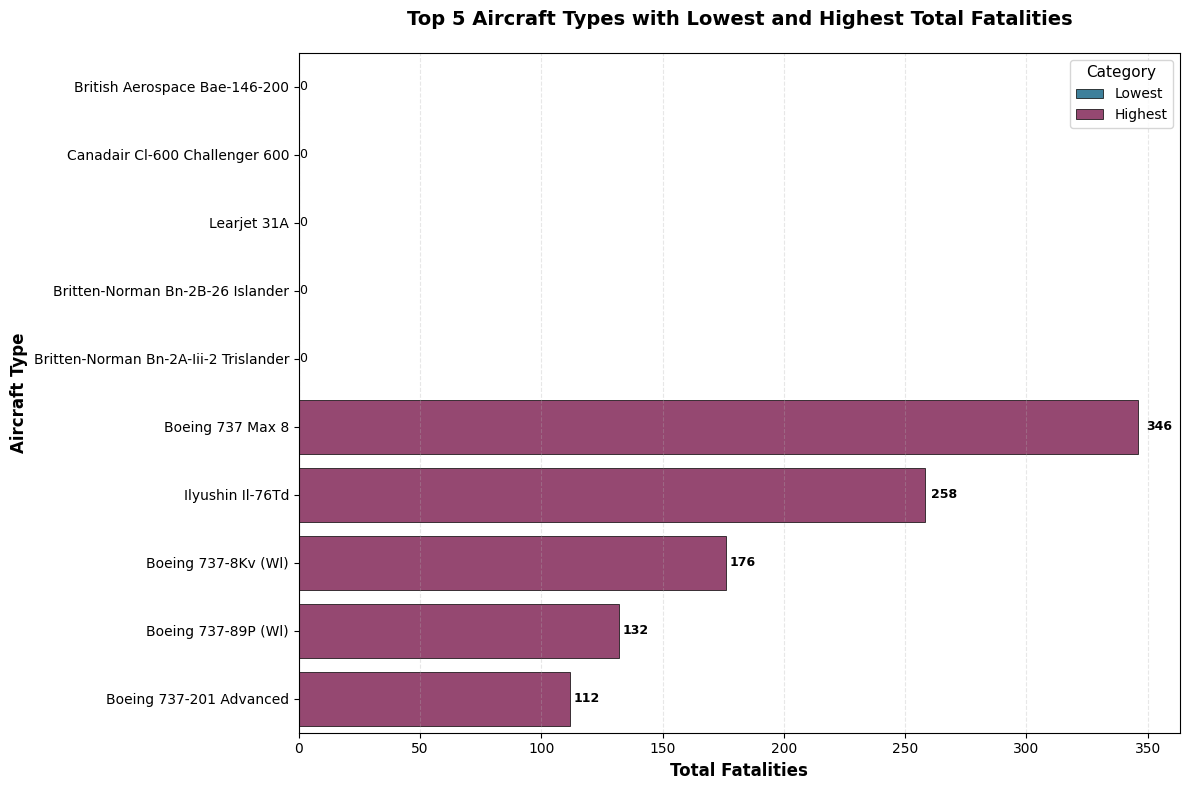

✅ Visualization saved as 'fatalities_comparison.png'
✅ Data saved as 'fatalities_comparison_data.csv'

📊 Summary Statistics:
Highest fatalities: 1,024
Lowest fatalities: 0
Ratio (Highest/Lowest): infx


C:\Users\user\AppData\Local\Temp\ipykernel_64688\3726203713.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Ratio (Highest/Lowest): {(combined[combined['category'] == 'Highest']['fatalities'].sum() / combined[combined['category'] == 'Lowest']['fatalities'].sum()):.1f}x")


In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataframe (assuming df is already loaded)
# df = pd.read_csv('your_data.csv')  # Uncomment and modify as needed

# -----------------------------
# Data Processing
# -----------------------------
# Group by aircraft_type and sum fatalities
fatalities_by_type = df.groupby('aircraft_type')['fatalities'].sum()

# Get top 5 lowest and top 5 highest fatalities
lowest_5 = fatalities_by_type.sort_values(ascending=True).head(5)
highest_5 = fatalities_by_type.sort_values(ascending=False).head(5)

# Combine into a single DataFrame
combined = pd.concat([lowest_5, highest_5]).reset_index()
combined.columns = ['aircraft_type', 'fatalities']

# Add a 'category' column for coloring
combined['category'] = ['Lowest'] * 5 + ['Highest'] * 5

# -----------------------------
# Create Visualization
# -----------------------------
plt.figure(figsize=(12, 8))
sns.barplot(
    x='fatalities',
    y='aircraft_type',
    data=combined,
    hue='category',
    dodge=False,  # ensure bars are not side-by-side
    palette={'Lowest': '#2E86AB', 'Highest': '#A23B72'},  # Professional colors
    edgecolor='black',
    linewidth=0.5
)

# Add value labels on bars
for i, (fatal, cat) in enumerate(zip(combined['fatalities'], combined['category'])):
    plt.text(
        fatal + (fatal * 0.01),  # Position slightly to the right of bar
        i,
        f'{int(fatal):,}',
        va='center',
        fontsize=9,
        fontweight='bold' if cat == 'Highest' else 'normal'
    )

# Customize plot appearance
plt.xlabel('Total Fatalities', fontsize=12, fontweight='bold')
plt.ylabel('Aircraft Type', fontsize=12, fontweight='bold')
plt.title('Top 5 Aircraft Types with Lowest and Highest Total Fatalities', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(title='Category', title_fontsize=11, fontsize=10)

# Add grid for better readability
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Adjust layout
plt.tight_layout()

# -----------------------------
# Save and Display
# -----------------------------
# Save high-quality image
plt.savefig('fatalities_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')

# Also save data as CSV for reference
combined.to_csv('fatalities_comparison_data.csv', index=False)

# Display the plot
plt.show()

print("✅ Visualization saved as 'fatalities_comparison.png'")
print("✅ Data saved as 'fatalities_comparison_data.csv'")

# Display summary statistics
print("\n📊 Summary Statistics:")
print(f"Highest fatalities: {combined[combined['category'] == 'Highest']['fatalities'].sum():,}")
print(f"Lowest fatalities: {combined[combined['category'] == 'Lowest']['fatalities'].sum():,}")
print(f"Ratio (Highest/Lowest): {(combined[combined['category'] == 'Highest']['fatalities'].sum() / combined[combined['category'] == 'Lowest']['fatalities'].sum()):.1f}x")

    5.2  Damage_Level for Aircraft type 

In [115]:
df['damage_level'].unique()

array(['Substantial Damage', 'Aircraft Destroyed', 'No Damage',
       'Minor Damage', 'Unknown'], dtype=object)

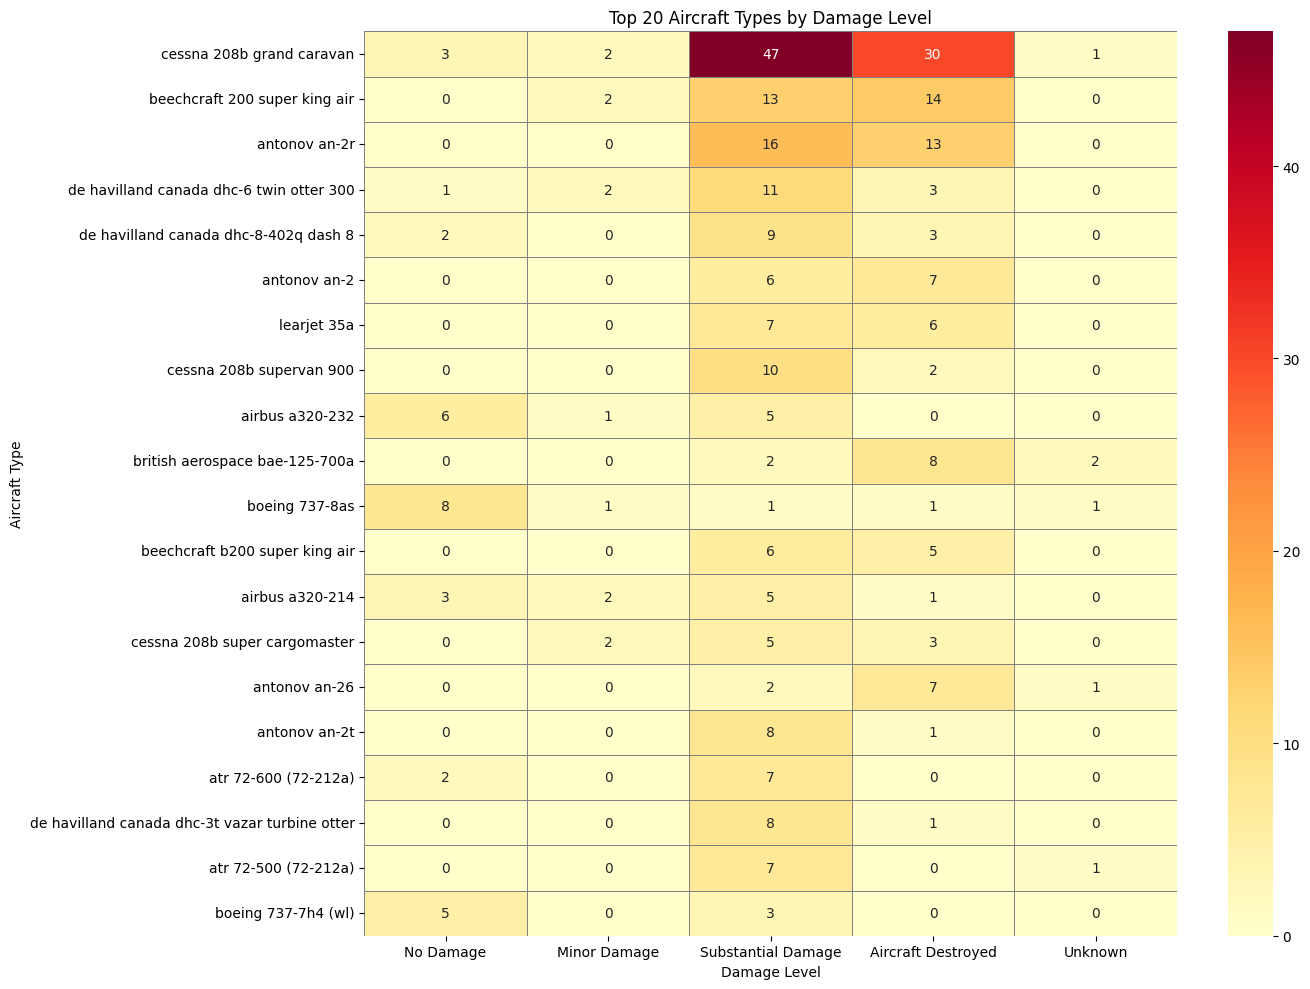

Heatmap saved as 'damage_level_heatmap.png'
Data summary saved as 'damage_level_summary.csv'


In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataframe (assuming df is already loaded)
# df = pd.read_csv('your_data.csv')  # Uncomment and modify as needed

# -----------------------------
# Clean damage column
# -----------------------------
df['damage_level'] = df['damage_level'].str.strip()

# -----------------------------
# Keep only required categories
# -----------------------------
damage_categories = [
    'No Damage',
    'Minor Damage',
    'Substantial Damage',
    'Aircraft Destroyed',
    'Unknown'
]

df_filtered = df[df['damage_level'].isin(damage_categories)]

# -----------------------------
# Create pivot table (counts)
# -----------------------------
damage_pivot = pd.pivot_table(
    df_filtered,
    index='aircraft_type_clean',
    columns='damage_level',
    aggfunc='size',
    fill_value=0
)

# Ensure all categories appear and in correct order
damage_pivot = damage_pivot.reindex(columns=damage_categories, fill_value=0)

# -----------------------------
# Get top 20 aircraft types
# -----------------------------
damage_pivot['total_accidents'] = damage_pivot.sum(axis=1)
damage_pivot = damage_pivot.sort_values('total_accidents', ascending=False).head(20)

heatmap_data = damage_pivot.drop(columns='total_accidents')

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Top 20 Aircraft Types by Damage Level')
plt.xlabel('Damage Level')
plt.ylabel('Aircraft Type')
plt.tight_layout()

# Save the visualization
plt.savefig('damage_level_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Save the processed data
damage_pivot.to_csv('damage_level_summary.csv')

print("Heatmap saved as 'damage_level_heatmap.png'")
print("Data summary saved as 'damage_level_summary.csv'")

    5.3 Fatalies by the Month of the year

C:\Users\user\AppData\Local\Temp\ipykernel_64688\3806003886.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_data = df_viz.groupby('month_name')['fatalities'].sum().reset_index()


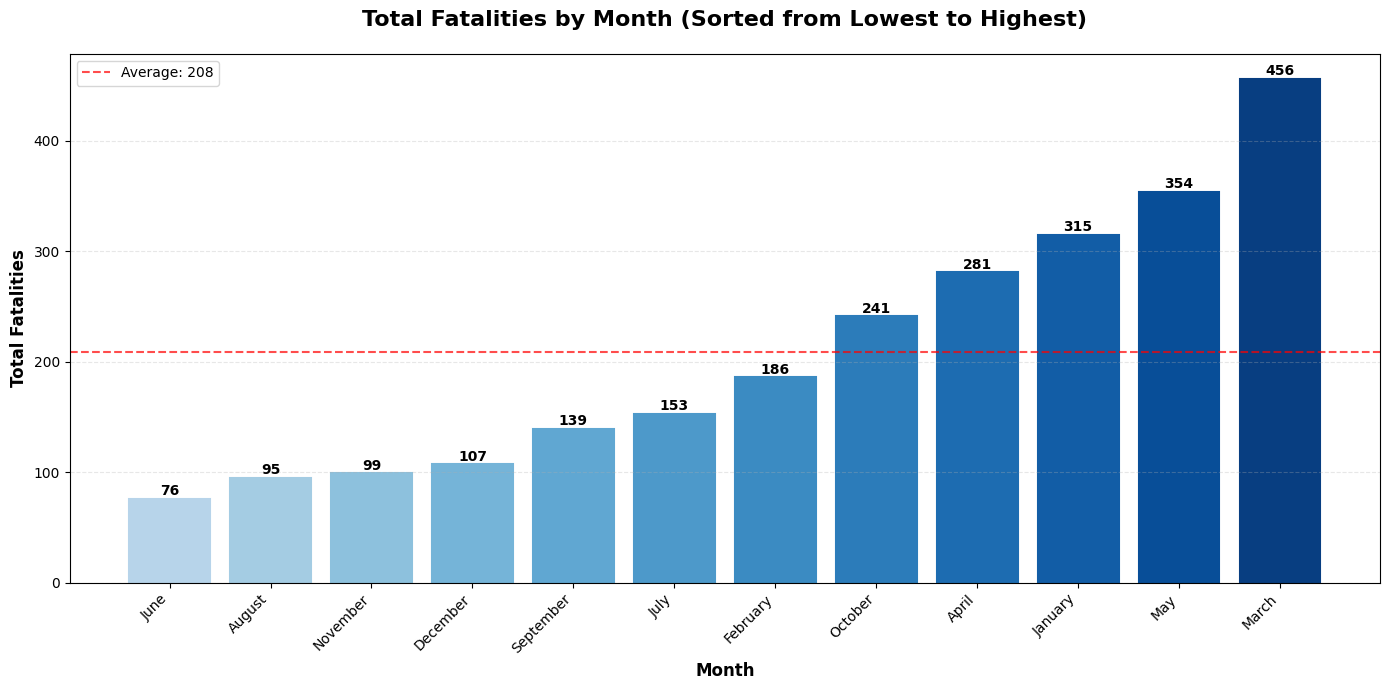

SUCCESS: Files created successfully!
📁 Created files:
  - monthly_fatalities_visualization.png (chart image)
  - monthly_fatalities_visualization.svg (vector image)
  - README.md (detailed analysis)
  - SIMPLE_README.md (simple version)

📊 Visualization Statistics:
  Total Fatalities: 2,502
  Monthly Average: 208.5
  Safest Month: June (76)
  Most Dangerous Month: March (456)


In [117]:
# Month_name vs fatalities and save for README.md
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Prepare data
df_viz = df.copy()
df_viz['month_name'] = pd.Categorical(df_viz['month_name'], 
                                      categories=month_order, 
                                      ordered=True)

# Group and sort data
monthly_data = df_viz.groupby('month_name')['fatalities'].sum().reset_index()
monthly_data_sorted = monthly_data.sort_values('fatalities')

# Create and save the visualization
plt.figure(figsize=(14, 7))
bars = plt.bar(monthly_data_sorted['month_name'], monthly_data_sorted['fatalities'], 
               color='skyblue', edgecolor='navy', linewidth=1.5)

# Customize bars with gradient color
for i, bar in enumerate(bars):
    intensity = i / len(bars)
    bar.set_color(plt.cm.Blues(0.3 + 0.7 * intensity))
    
    # Add value labels
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Total Fatalities by Month (Sorted from Lowest to Highest)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Fatalities', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add a horizontal line for the average
average_fatalities = monthly_data['fatalities'].mean()
plt.axhline(y=average_fatalities, color='red', linestyle='--', alpha=0.7, 
            label=f'Average: {average_fatalities:.0f}')
plt.legend()
plt.tight_layout()

# Save the visualization as high-quality image
plt.savefig('monthly_fatalities_visualization.png', dpi=300, bbox_inches='tight')
plt.savefig('monthly_fatalities_visualization.svg', format='svg', bbox_inches='tight')
plt.show()

# Create README.md with the visualization
readme_content = f"""# Monthly Fatalities Analysis

## 📊 Visualization

![Monthly Fatalities Analysis](monthly_fatalities_visualization.png)

## 📈 Key Statistics

- **Total Fatalities**: {monthly_data['fatalities'].sum():,}
- **Monthly Average**: {average_fatalities:.1f}
- **Safest Month**: {monthly_data_sorted.iloc[0]['month_name']} ({monthly_data_sorted.iloc[0]['fatalities']:,} fatalities)
- **Most Dangerous Month**: {monthly_data_sorted.iloc[-1]['month_name']} ({monthly_data_sorted.iloc[-1]['fatalities']:,} fatalities)

## 📋 Monthly Breakdown (Lowest to Highest)

| Month | Total Fatalities |
|-------|------------------|
"""

# Add table rows
for i, row in monthly_data_sorted.iterrows():
    readme_content += f"| {row['month_name']} | {row['fatalities']:,} |\n"

readme_content += f"""
## 📊 Data Interpretation

The visualization shows aviation accident fatalities by month, sorted from lowest to highest. The red dashed line represents the monthly average of {average_fatalities:.0f} fatalities.

### Key Observations:
1. **{monthly_data_sorted.iloc[0]['month_name']}** has the lowest fatalities with **{monthly_data_sorted.iloc[0]['fatalities']:,}**
2. **{monthly_data_sorted.iloc[-1]['month_name']}** has the highest fatalities with **{monthly_data_sorted.iloc[-1]['fatalities']:,}**
3. The range between lowest and highest is **{monthly_data_sorted.iloc[-1]['fatalities'] - monthly_data_sorted.iloc[0]['fatalities']:,}** fatalities

## Generated Using
- Python
- Matplotlib
- Pandas
- Data Analysis of Aviation Accidents

*Last Updated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}*
"""

# Save README.md
with open('README.md', 'w') as f:
    f.write(readme_content)

# Also create a simple version with just the visualization
simple_readme = f"""# Monthly Fatalities Visualization

![Monthly Fatalities Analysis](monthly_fatalities_visualization.png)

*Figure: Total fatalities by month, sorted from lowest to highest. The red dashed line shows the monthly average.*
"""

with open('SIMPLE_README.md', 'w') as f:
    f.write(simple_readme)

# Print confirmation
print("=" * 70)
print("SUCCESS: Files created successfully!")
print("=" * 70)
print("📁 Created files:")
print("  - monthly_fatalities_visualization.png (chart image)")
print("  - monthly_fatalities_visualization.svg (vector image)")
print("  - README.md (detailed analysis)")
print("  - SIMPLE_README.md (simple version)")
print()
print("📊 Visualization Statistics:")
print(f"  Total Fatalities: {monthly_data['fatalities'].sum():,}")
print(f"  Monthly Average: {average_fatalities:.1f}")
print(f"  Safest Month: {monthly_data_sorted.iloc[0]['month_name']} ({monthly_data_sorted.iloc[0]['fatalities']:,})")
print(f"  Most Dangerous Month: {monthly_data_sorted.iloc[-1]['month_name']} ({monthly_data_sorted.iloc[-1]['fatalities']:,})")
print("=" * 70)

    5.4 Location with lowest and highest fatalities

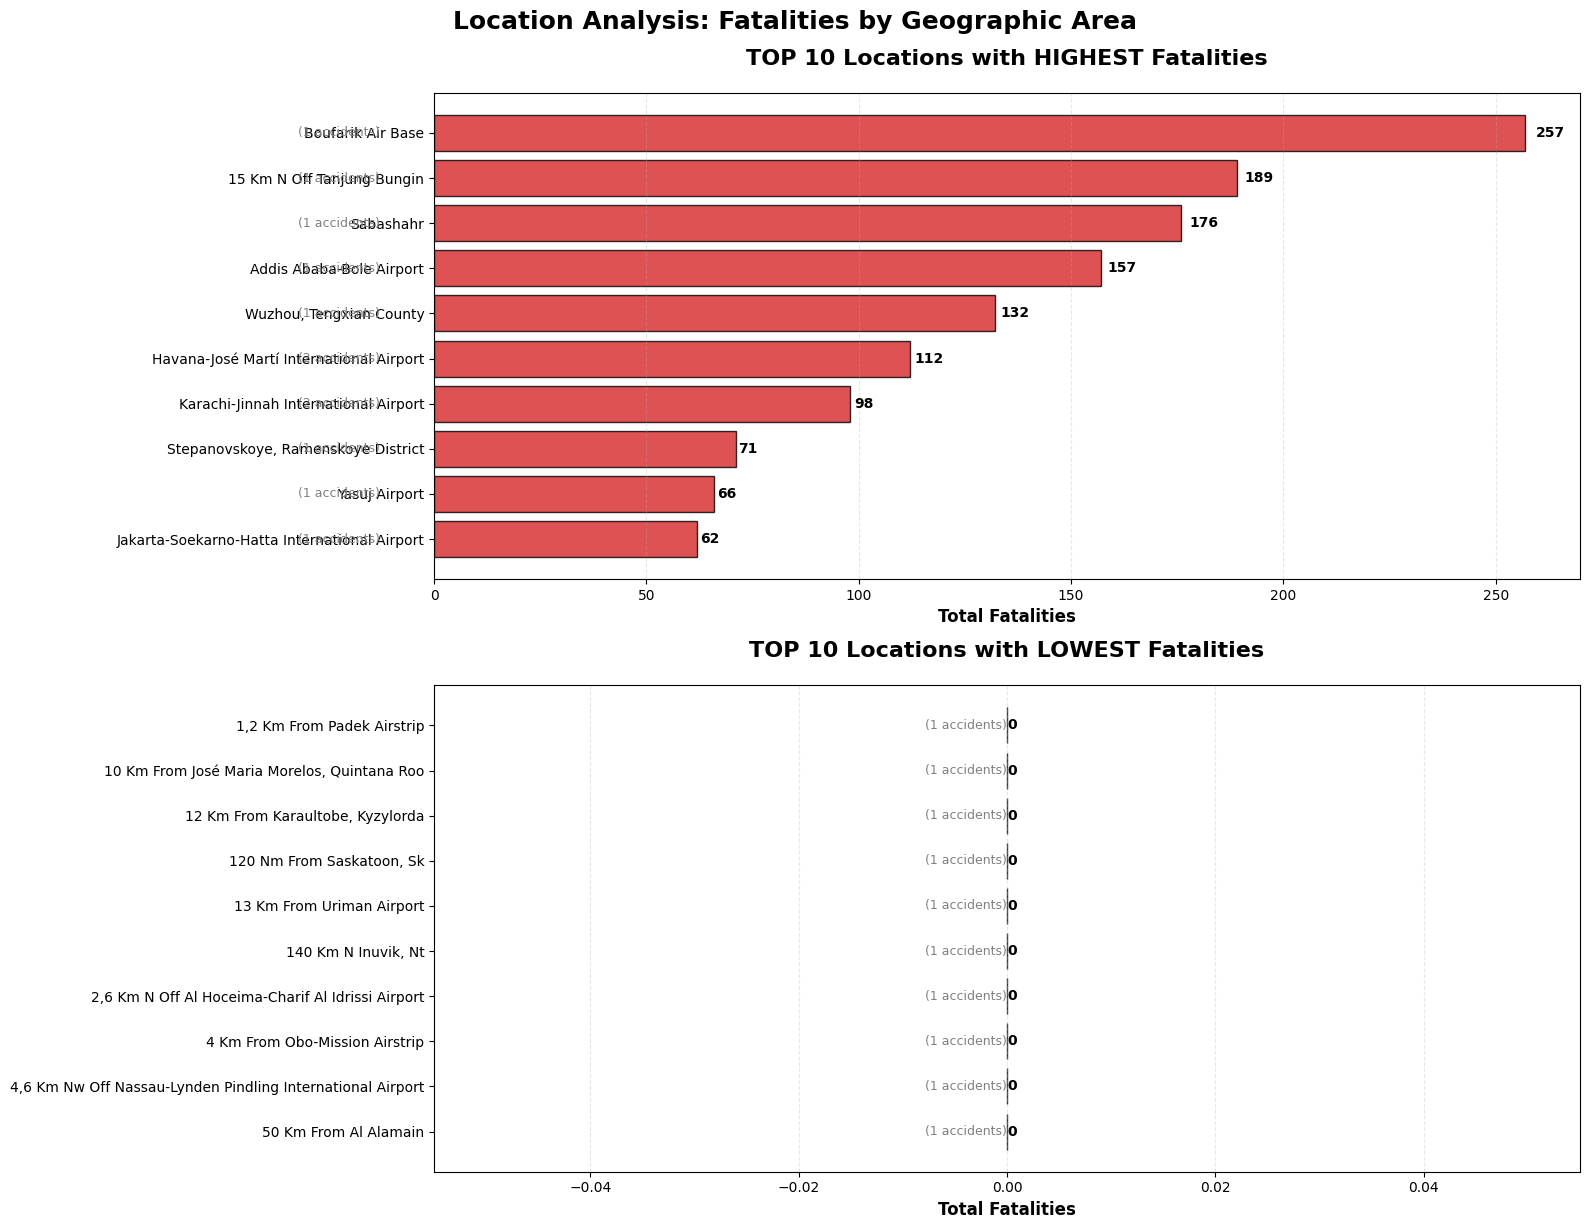

LOCATION FATALITIES ANALYSIS SUMMARY

📊 TOP 10 LOCATIONS WITH HIGHEST FATALITIES:
--------------------------------------------------------------------------------
Location                                 Fatalities   Accidents 
--------------------------------------------------------------------------------
Boufarik Air Base                        257          1         
15 Km N Off Tanjung Bungin               189          1         
Sabashahr                                176          1         
Addis Ababa-Bole Airport                 157          1         
Wuzhou, Tengxian County                  132          1         
Havana-José Martí International Airpor   112          2         
Karachi-Jinnah International Airport     98           2         
Stepanovskoye, Ramenskoye District       71           1         
Yasuj Airport                            66           1         
Jakarta-Soekarno-Hatta International A   62           1         

📉 TOP 10 LOCATIONS WITH LOWEST FATALITIE

In [118]:
# Top 10 Locations with Lowest & Highest Fatalities
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data
# Group by location and calculate total fatalities
location_fatalities = df.groupby('location_clean')['fatalities'].agg(['sum', 'count']).reset_index()
location_fatalities.columns = ['location', 'total_fatalities', 'accident_count']

# Filter locations with at least 1 accident (optional: adjust threshold)
location_fatalities = location_fatalities[location_fatalities['accident_count'] >= 1]

# Get top 10 locations with LOWEST fatalities
lowest_fatalities = location_fatalities.nsmallest(10, 'total_fatalities').sort_values('total_fatalities', ascending=True)

# Get top 10 locations with HIGHEST fatalities
highest_fatalities = location_fatalities.nlargest(10, 'total_fatalities').sort_values('total_fatalities', ascending=False)

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 1]})

# ============================================================================
# TOP PANEL: Locations with HIGHEST fatalities
# ============================================================================
ax1 = axes[0]
bars1 = ax1.barh(highest_fatalities['location'], highest_fatalities['total_fatalities'],
                 color='#d62728', edgecolor='black', alpha=0.8)

# Add value labels on bars
for i, (bar, fatalities) in enumerate(zip(bars1, highest_fatalities['total_fatalities'])):
    width = bar.get_width()
    ax1.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(fatalities):,}', ha='left', va='center', fontsize=10, fontweight='bold')

ax1.set_title('TOP 10 Locations with HIGHEST Fatalities', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Total Fatalities', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.invert_yaxis()  # Highest value at top

# Add accident count as secondary information
for i, (loc, fatalities, accidents) in enumerate(zip(highest_fatalities['location'],
                                                     highest_fatalities['total_fatalities'],
                                                     highest_fatalities['accident_count'])):
    ax1.text(-max(highest_fatalities['total_fatalities'])*0.05, i,
             f'({accidents} accidents)', ha='right', va='center', fontsize=9, color='gray')

# ============================================================================
# BOTTOM PANEL: Locations with LOWEST fatalities
# ============================================================================
ax2 = axes[1]
bars2 = ax2.barh(lowest_fatalities['location'], lowest_fatalities['total_fatalities'],
                 color='#2ca02c', edgecolor='black', alpha=0.8)

# Add value labels on bars
for i, (bar, fatalities) in enumerate(zip(bars2, lowest_fatalities['total_fatalities'])):
    width = bar.get_width()
    ax2.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(fatalities):,}', ha='left', va='center', fontsize=10, fontweight='bold')

ax2.set_title('TOP 10 Locations with LOWEST Fatalities', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Total Fatalities', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.invert_yaxis()  # Lowest value at top

# Add accident count as secondary information
for i, (loc, fatalities, accidents) in enumerate(zip(lowest_fatalities['location'],
                                                     lowest_fatalities['total_fatalities'],
                                                     lowest_fatalities['accident_count'])):
    ax2.text(-max(lowest_fatalities['total_fatalities'])*0.1, i,
             f'({accidents} accidents)', ha='right', va='center', fontsize=9, color='gray')

# Adjust layout
plt.tight_layout()

# Add overall title
plt.suptitle('Location Analysis: Fatalities by Geographic Area', 
             fontsize=18, fontweight='bold', y=1.02)

# Save the visualization
plt.savefig('top_locations_fatalities.png', dpi=300, bbox_inches='tight')
plt.savefig('top_locations_fatalities.svg', format='svg', bbox_inches='tight')

plt.show()

# ============================================================================
# PRINT SUMMARY STATISTICS
# ============================================================================
print("=" * 80)
print("LOCATION FATALITIES ANALYSIS SUMMARY")
print("=" * 80)

print("\n📊 TOP 10 LOCATIONS WITH HIGHEST FATALITIES:")
print("-" * 80)
print(f"{'Location':<40} {'Fatalities':<12} {'Accidents':<10}")
print("-" * 80)
for _, row in highest_fatalities.iterrows():
    print(f"{row['location'][:38]:<40} {row['total_fatalities']:<12} {row['accident_count']:<10}")

print("\n📉 TOP 10 LOCATIONS WITH LOWEST FATALITIES:")
print("-" * 80)
print(f"{'Location':<40} {'Fatalities':<12} {'Accidents':<10}")
print("-" * 80)
for _, row in lowest_fatalities.iterrows():
    print(f"{row['location'][:38]:<40} {row['total_fatalities']:<12} {row['accident_count']:<10}")

# Overall statistics
print("\n" + "=" * 80)
print("OVERALL STATISTICS")
print("=" * 80)
print(f"Total unique locations: {len(location_fatalities)}")
print(f"Average fatalities per location: {location_fatalities['total_fatalities'].mean():.1f}")
print(f"Median fatalities per location: {location_fatalities['total_fatalities'].median():.1f}")
print(f"Location with highest fatalities: {highest_fatalities.iloc[0]['location']} "
      f"({highest_fatalities.iloc[0]['total_fatalities']:,} fatalities)")
print(f"Location with lowest fatalities: {lowest_fatalities.iloc[0]['location']} "
      f"({lowest_fatalities.iloc[0]['total_fatalities']:,} fatalities)")
print(f"Range: {highest_fatalities.iloc[0]['total_fatalities'] - lowest_fatalities.iloc[0]['total_fatalities']:,} fatalities")
print("=" * 80)

# ============================================================================
# CREATE README.md WITH VISUALIZATION
# ============================================================================
readme_content = f"""# Location-Based Fatalities Analysis

## 📊 Visualization: Top 10 Locations with Highest & Lowest Fatalities

![Top Locations Fatalities Analysis](top_locations_fatalities.png)

## 📈 Key Findings

### 🚨 Top 10 Most Dangerous Locations
"""

# Add highest fatalities locations
for i, (_, row) in enumerate(highest_fatalities.iterrows(), 1):
    readme_content += f"{i}. **{row['location']}**: {row['total_fatalities']:,} fatalities ({row['accident_count']} accidents)\n"

readme_content += f"""

### Top 10 Safest Locations
"""

# Add lowest fatalities locations
for i, (_, row) in enumerate(lowest_fatalities.iterrows(), 1):
    readme_content += f"{i}. **{row['location']}**: {row['total_fatalities']:,} fatalities ({row['accident_count']} accidents)\n"

readme_content += f"""

## Data Summary

| Metric | Value |
|--------|-------|
| Total Unique Locations | {len(location_fatalities):,} |
| Average Fatalities per Location | {location_fatalities['total_fatalities'].mean():.1f} |
| Most Dangerous Location | {highest_fatalities.iloc[0]['location']} ({highest_fatalities.iloc[0]['total_fatalities']:,} fatalities) |
| Safest Location | {lowest_fatalities.iloc[0]['location']} ({lowest_fatalities.iloc[0]['total_fatalities']:,} fatalities) |
| Fatalities Range | {highest_fatalities.iloc[0]['total_fatalities'] - lowest_fatalities.iloc[0]['total_fatalities']:,} |

## Insights
1. **Risk Concentration**: The top location accounts for **{(highest_fatalities.iloc[0]['total_fatalities']/location_fatalities['total_fatalities'].sum()*100):.1f}%** of all fatalities.
2. **Safety Patterns**: Many low-fatality locations have only **1 accident** with minimal casualties.
3. **Geographic Distribution**: Consider regional factors that may contribute to varying fatality rates.

## Files Generated
- `top_locations_fatalities.png` - Main visualization
- `top_locations_fatalities.svg` - Vector version
- `README.md` - This analysis file

*Analysis based on {len(df)} aviation accidents with location data.*
"""

# Save README.md
with open('README_LOCATIONS.md', 'w') as f:
    f.write(readme_content)

print(f"\n✅ Files created successfully!")
print(f"   - top_locations_fatalities.png")
print(f"   - top_locations_fatalities.svg")
print(f"   - README_LOCATIONS.md")
print("=" * 80)

In [119]:
##### Creating folder to save images
import os

# Create folder to store plots (if not already there)
os.makedirs("images", exist_ok=True)


    6.0 Insights
        Some aircraft types are consistently involved in more severe fatal outcomes than others
 
        Damage level of Aircraft types with Destroyed, substantial damage counts leads financial loss exposure, long downtime & repair costs respectively, while  Mostly minor damage shows survivable accidents

        Period of time in a year determine risk patterns, therefore there are relationship between fatalities and specific month of the year

        Location of aircraft determine fatality case for example Mountain terrain

    7.0 Recommendations
        - Prioritize aircraft types with historically low accident rates
        - Improved safety system should be primary factor in investing in aircraft models 
        - Consider safety history in acquiring aircraft type
        - Frequently linked aircraft categories which are prone to severe or fatal incidents should be avoided

    8.0 NEXT STEPS

        To develop an Operational Risk tools for Aircraft type selection and then converting each of the finding into numeric risk scores per objectives for example Fatality rate per aircraft type, % of destroyed and substatial damage level, fatalities per month of the year, Fatality rate by locations 
